In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'coalsegmentation:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F5350177%2F8899404%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240708%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240708T152255Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D41e9626532c89c72a0dbfe337393be4d63b3cd658fabb55b87c8462ae72863f7ac7711f7d967bcd905500fcfff057cfbe3ff11173acd7ba04288114b26d3b7da43f8e2e9bbed679cfe9ec7d520f8e7ce0438657de9103535a021a9458e12d4f439bdc0ff1ad63b44d04030171ee2b71cef2f9f9e7c99af1bba088ce30b90c76476375416895df60d9689c25d6e7e22aed6911de7ba4dd3d45e6fd9a81c0236403294adadfb9e4ae6e9f2b2f8302fede78b6e51d9e6d0dda6e54777896149c2a960685fc96903a227c4cda3dbb8ff5d34420efe94a8c5867543fa7431344e36ea84c2f55bdc5a3028a52f005059c030e57be086d7c8fd20988a8a698227aaa86b'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 226469591 bytes downloaded
Downloaded and uncompressed: coalsegmentation
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
pip install Augmentor

X_train shape is:  (95, 128, 128, 3)
Y_train shape is:  (95, 128, 128, 1)


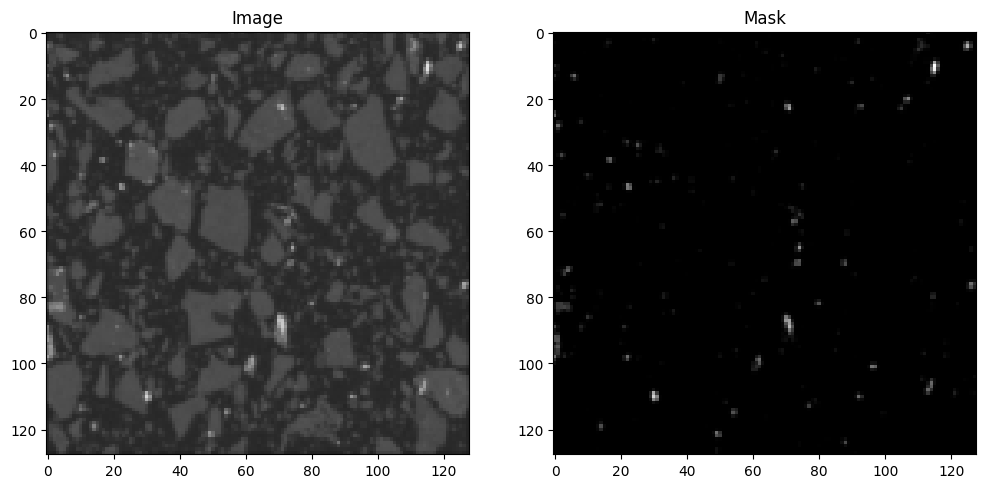

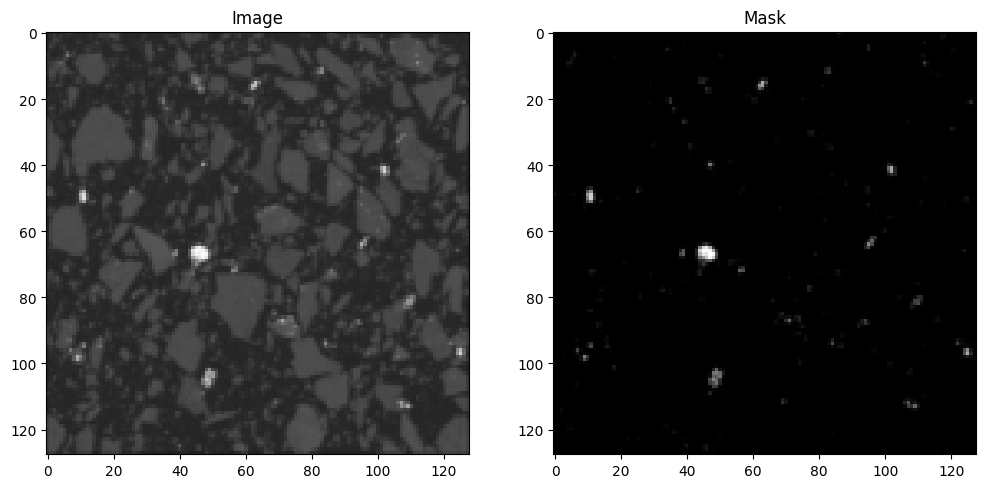

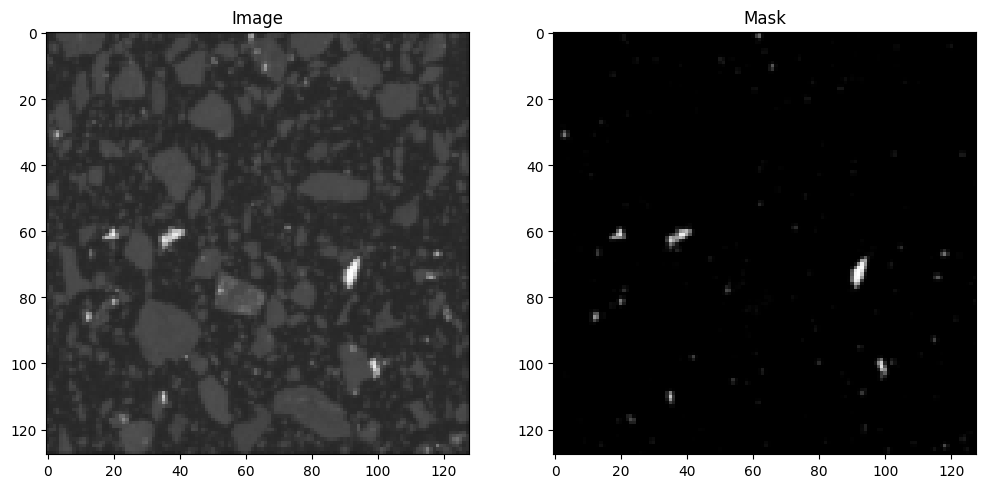

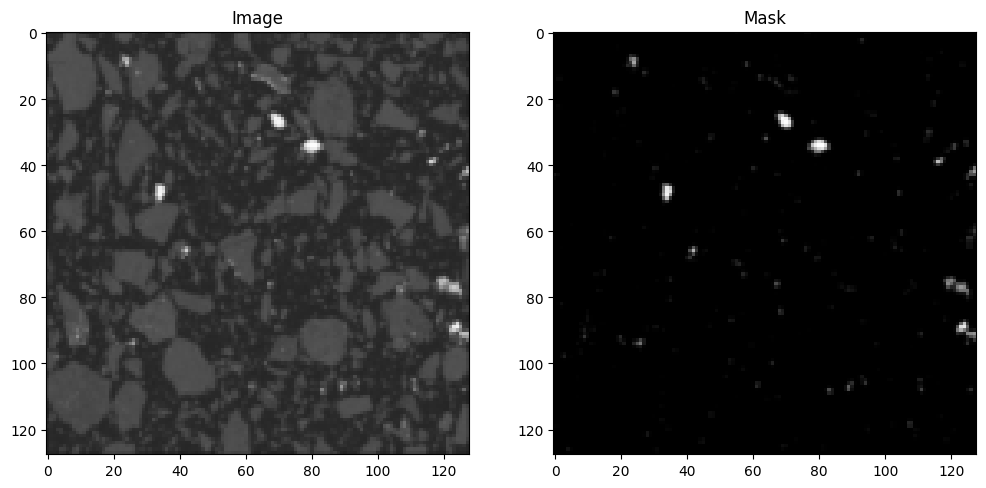

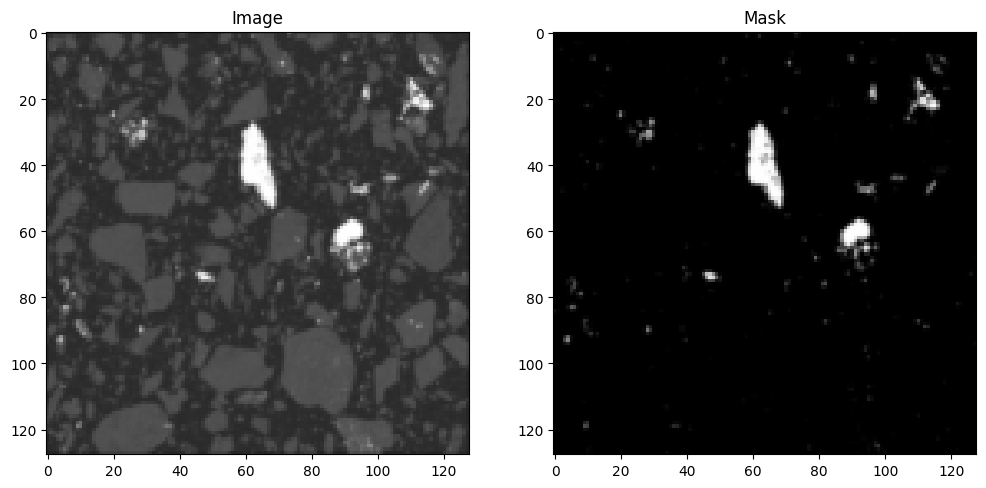

Unique values in the masks: [0 1]


In [ ]:
import tensorflow as tf
import cv2
import os
import numpy as np
from skimage.io import imread, imshow
from skimage.transform import resize
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

img_width = 128
img_height = 128
img_channels = 3

def is_image_file(filename):
    # Define image extensions you want to consider
    extensions = ['.jpg', '.jpeg', '.png', '.bmp']
    for ext in extensions:
        if filename.lower().endswith(ext):
            return True
    return False

Train_path_x = '/kaggle/input/coalsegmentation/Criepi2009_1_Tif_CCSEM_150x/images'
Train_path_y = '/kaggle/input/coalsegmentation/Criepi2009_1_Tif_CCSEM_150x/masks'

#Test_path_x = '/ASuketh/signature_fraud_cheques/bsdc_dataset/TestSet/X'
#Test_path_y = '/ASuketh/signature_fraud_cheques/bsdc_dataset/TestSet/y'

# Get list of image files
train_files_x = next(os.walk(Train_path_x))[2]
train_files_y = next(os.walk(Train_path_y))[2]

# Initialize arrays
X_train = np.zeros((len(train_files_x), img_width, img_height, 3), dtype=np.uint8)
Y_train = np.zeros((len(train_files_y), img_width, img_height, 1), dtype=np.uint8)

# Load X_train images
n = 0
for filename in train_files_x:
    if is_image_file(filename):
        image_path = os.path.join(Train_path_x, filename)
        image = imread(image_path)
        #if image.ndim == 3:
            #image = rgb2gray(image)  # Convert to grayscale if necessary
        #image = np.expand_dims(resize(image, (img_height, img_width), mode='constant', preserve_range=True), axis=-1)
        image = resize(image, (img_height, img_width), mode='constant', preserve_range=True)
        new_image = np.stack((image,) * 3, axis=-1)

        X_train[n] = new_image
        n += 1

# Load Y_train images
n = 0
for filename in train_files_y:
    if is_image_file(filename):
        image_path = os.path.join(Train_path_y, filename)
        image = imread(image_path)
        if image.ndim == 3:
            image = rgb2gray(image)  # Convert to grayscale if necessary
        image = np.expand_dims(resize(image, (img_height, img_width), mode='constant', preserve_range=True), axis=-1)
        Y_train[n] = image
        n += 1


print("X_train shape is: ", X_train.shape)
print("Y_train shape is: ", Y_train.shape)

import matplotlib.pyplot as plt

def display_image_and_mask(image, mask):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(image)
    ax[0].set_title('Image')
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title('Mask')
    plt.show()

# Display some samples
for i in range(5):
    display_image_and_mask(X_train[i], Y_train[i])

# Convert masks to binary
Y_train_binary = (Y_train > 0).astype(np.uint8)


print("Unique values in the masks:", np.unique(Y_train_binary))




In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, Dropout, MaxPooling2D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K


kernel_initializer = 'he_normal'


inputs = tf.keras.layers.Input((img_width, img_height, img_channels))

#remember these below layers take only floating point values as inputs we have to convert the inputs to floating point values
s = tf.keras.layers.Lambda(lambda x: x/255)(inputs)
c1 = tf.keras.layers.Conv2D(16, (3,3), activation = 'relu', kernel_initializer = kernel_initializer, padding = 'same')(s)
c1 = tf.keras.layers.Dropout(0.1)(c1)
c1 = tf.keras.layers.Conv2D(16, (3,3), activation = 'relu', kernel_initializer = kernel_initializer, padding = 'same')(c1)
p1 = tf.keras.layers.MaxPooling2D((2,2))(c1)

c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p1)
c2 = Dropout(0.1)(c2)
c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c2)
p2 = MaxPooling2D((2, 2))(c2)

c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p2)
c3 = Dropout(0.2)(c3)
c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c3)
p3 = MaxPooling2D((2, 2))(c3)

c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p3)
c4 = Dropout(0.2)(c4)
c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c4)
p4 = MaxPooling2D(pool_size=(2, 2))(c4)

c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p4)
c5 = Dropout(0.3)(c5)
c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c5)

#Expansive path
u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
u6 = concatenate([u6, c4])
c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u6)
c6 = Dropout(0.2)(c6)
c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c6)

u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
u7 = concatenate([u7, c3])
c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u7)
c7 = Dropout(0.2)(c7)
c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c7)

u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
u8 = concatenate([u8, c2])
c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u8)
c8 = Dropout(0.1)(c8)
c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c8)

u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
u9 = concatenate([u9, c1], axis=3)
c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u9)
c9 = Dropout(0.1)(c9)
c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c9)

outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

model = Model(inputs=[inputs], outputs=[outputs])
model.compile(optimizer=Adam(learning_rate = 0.00001), loss='binary_crossentropy', metrics=['accuracy'])
#model.compile(optimizer=Adam(lr = 1e-3), loss='binary_crossentropy', metrics=[MeanIoU(num_classes=2)])
model.summary()







Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 lambda_2 (Lambda)           (None, 128, 128, 3)          0         ['input_3[0][0]']             
                                                                                                  
 conv2d_38 (Conv2D)          (None, 128, 128, 16)         448       ['lambda_2[0][0]']            
                                                                                                  
 dropout_18 (Dropout)        (None, 128, 128, 16)         0         ['conv2d_38[0][0]']           
                                                                                            

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

# Callbacks
callbacks = [
    #EarlyStopping(patience=2, monitor='val_loss', restore_best_weights=True),  # Optional: stops training early if no improvement
    TensorBoard(log_dir='./logs', histogram_freq=1)
]

# Training the model
results = model.fit(
    X_train, Y_train,
    validation_split=0.1,
    batch_size=8,
    epochs=25,
    callbacks=callbacks
)

# Summary of the results
print(results.history)


Epoch 1/25
11/11 [==============================] - 21s 1s/step - loss: 1.0705 - accuracy: 0.8519 - val_loss: 0.9169 - val_accuracy: 0.9016
Epoch 2/25
11/11 [==============================] - 14s 1s/step - loss: 1.0133 - accuracy: 0.8247 - val_loss: 0.8673 - val_accuracy: 0.8636
Epoch 3/25
11/11 [==============================] - 15s 1s/step - loss: 0.9555 - accuracy: 0.7943 - val_loss: 0.8241 - val_accuracy: 0.7964
Epoch 4/25
11/11 [==============================] - 15s 1s/step - loss: 0.9147 - accuracy: 0.7607 - val_loss: 0.7847 - val_accuracy: 0.6982
Epoch 5/25
11/11 [==============================] - 15s 1s/step - loss: 0.8738 - accuracy: 0.7246 - val_loss: 0.7498 - val_accuracy: 0.5838
Epoch 6/25
11/11 [==============================] - 15s 1s/step - loss: 0.8393 - accuracy: 0.6851 - val_loss: 0.7181 - val_accuracy: 0.4681
Epoch 7/25
11/11 [==============================] - 15s 1s/step - loss: 0.8056 - accuracy: 0.6433 - val_loss: 0.6885 - val_accuracy: 0.3581
Epoch 8/25
11/11 [==